In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_dropout_dataset.csv")
print(f"Shape: {df.shape}")
print(df.head())

Shape: (5000, 15)
  student_id  age      region enroll_date  exam_season  courses_enrolled  \
0   STU00001   26  Alexandria  2024-01-13            0                 3   
1   STU00002   23       Amman  2024-05-05            0                 6   
2   STU00003   17       Dubai  2024-03-12            0                 3   
3   STU00004   23  Alexandria  2024-12-12            0                 6   
4   STU00005   20     Baghdad  2024-02-14            0                 5   

   completed_assignments  completion_rate  login_frequency  \
0                      5           0.3571             5.29   
1                      0           0.0000             0.84   
2                      1           0.0435             1.79   
3                     13           0.4396             0.78   
4                      5           0.2078             0.92   

   last_activity_days_ago  forum_posts_count  dropout_score  label  \
0                      10                  5         0.1064      0   
1           

In [ ]:
print("=== Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Descriptive Statistics ===")
print(df.describe())

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              500

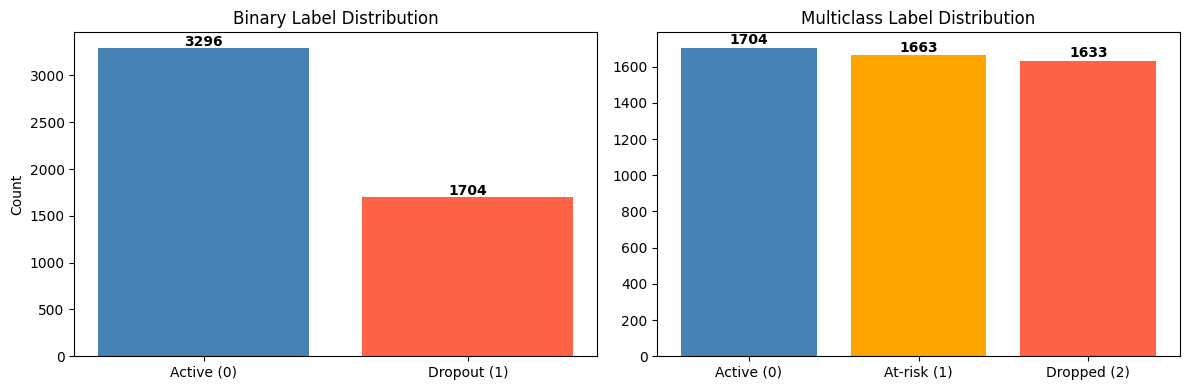

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary label
label_counts = df["label"].value_counts()
axes[0].bar(["Active (0)", "Dropout (1)"],
            label_counts.values,
            color=["steelblue", "tomato"])
axes[0].set_title("Binary Label Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Multiclass label
mc_counts = df["label_multiclass"].value_counts().sort_index()
axes[1].bar(["Active (0)", "At-risk (1)", "Dropped (2)"],
            mc_counts.values,
            color=["steelblue", "orange", "tomato"])
axes[1].set_title("Multiclass Label Distribution")
for i, v in enumerate(mc_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

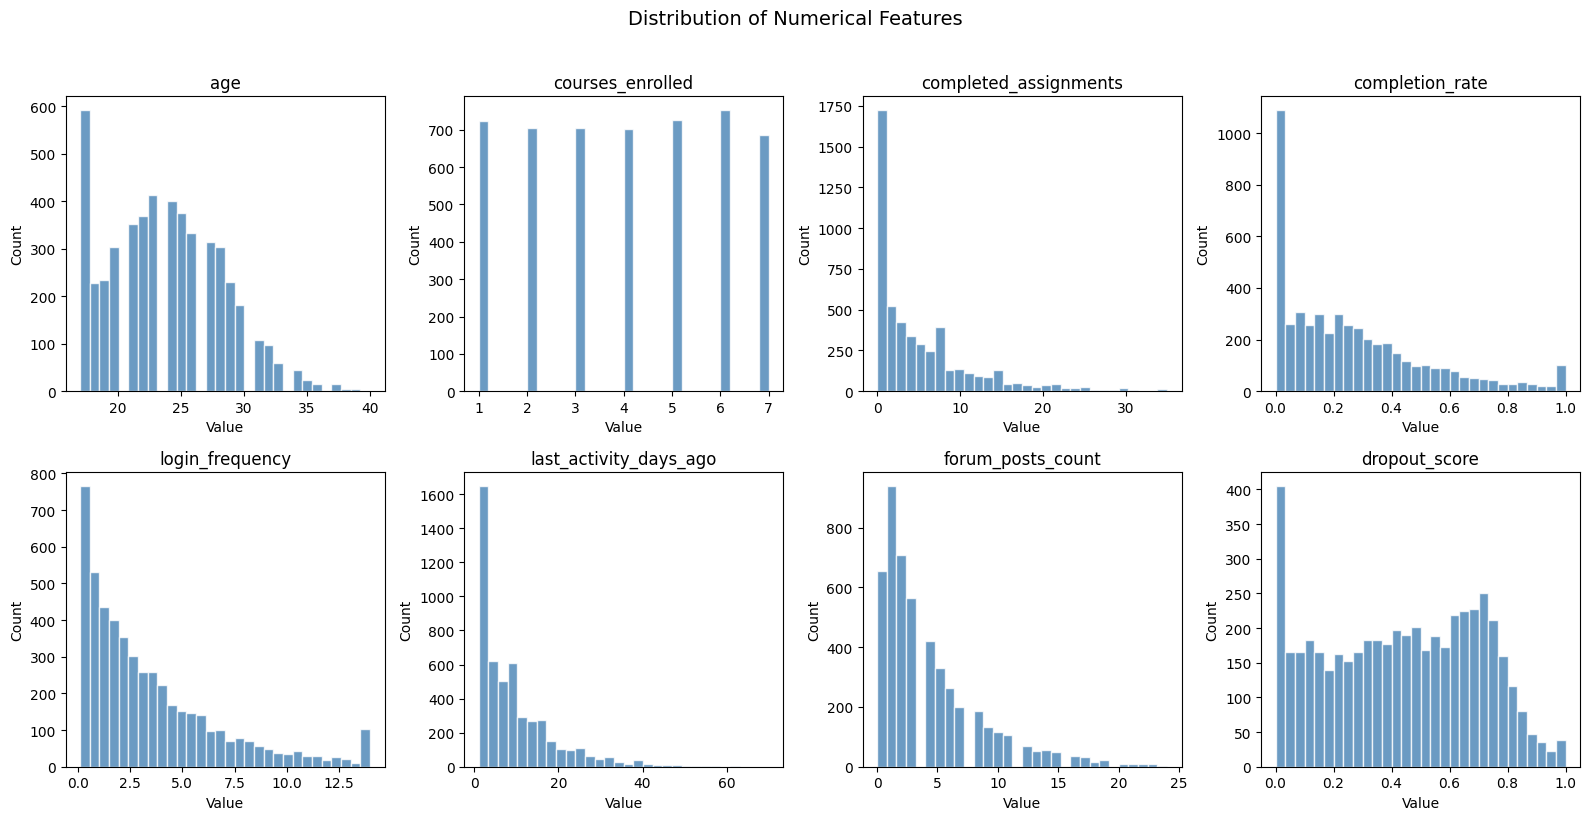

In [ ]:
num_cols = ["age", "courses_enrolled", "completed_assignments",
            "completion_rate", "login_frequency",
            "last_activity_days_ago", "forum_posts_count", "dropout_score"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution of Numerical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2871/1352402503.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_class, labels=["Active", "At-risk", "Dropped"])
/tmp/ipykernel_2871/1352402503.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_class, labels=["Active", "At-risk", "Dropped"])
/tmp/ipykernel_2871/1352402503.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_class, labels=["Active", "At-risk", "Dropped"])
/tmp/ipykernel_2871/1352402503.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; supp

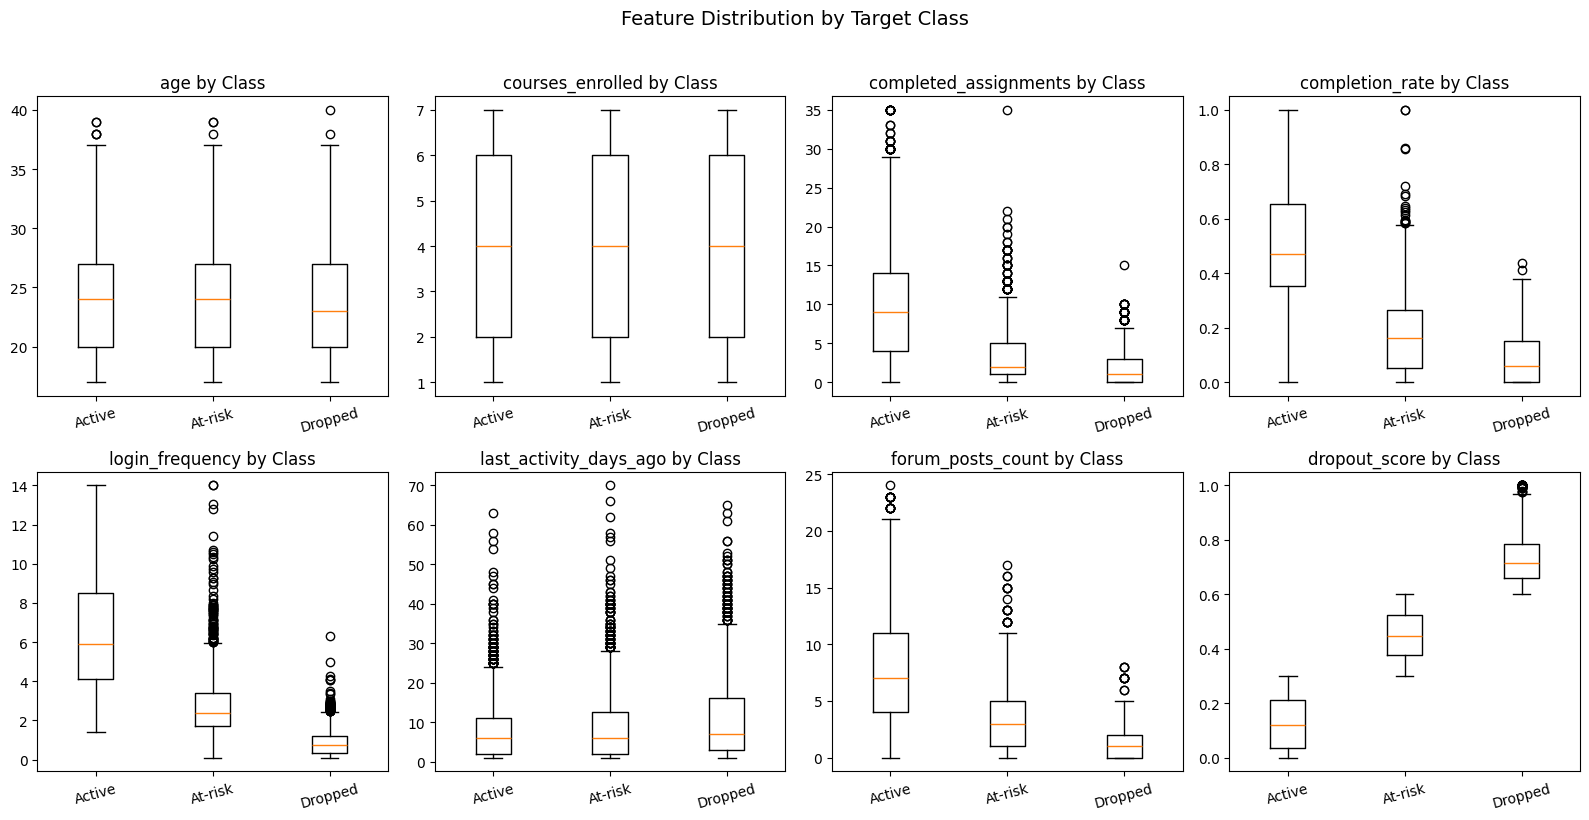

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_by_class = [df[df["label_multiclass"] == cls][col].values
                     for cls in [0, 1, 2]]
    axes[i].boxplot(data_by_class, labels=["Active", "At-risk", "Dropped"])
    axes[i].set_title(f"{col} by Class")
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Feature Distribution by Target Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

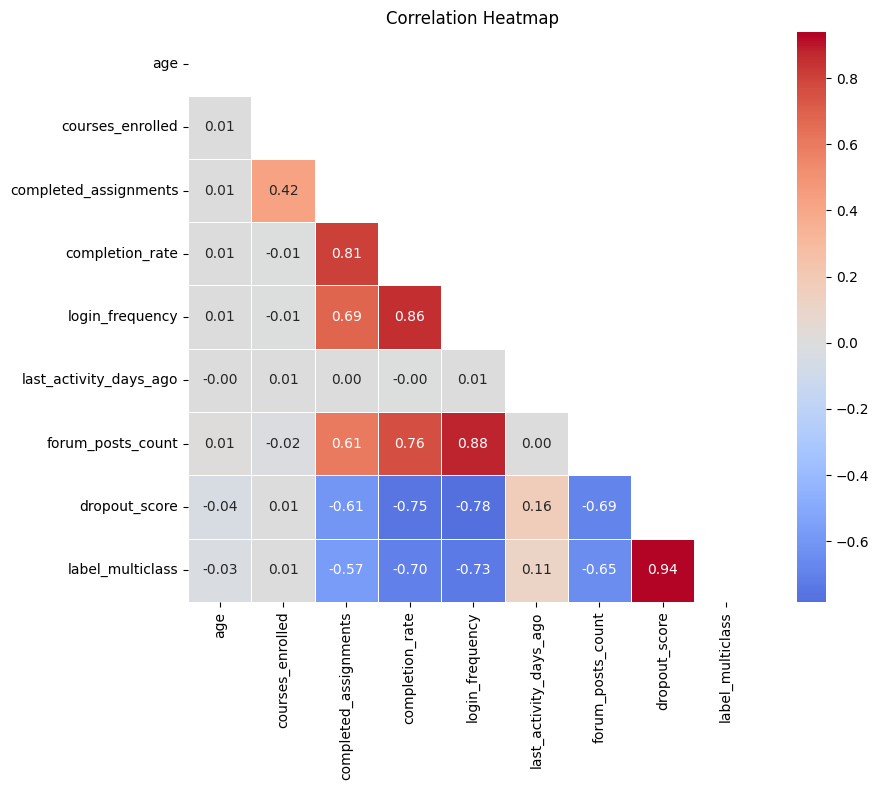

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ["label_multiclass"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()